In [1]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Path and categories
data_path = 'E:\\baby cry detector\\dataset'
categories = ['baby_cry', 'baby_laugh', 'silence', 'noise']

# Parameters
sr = 22050  # Sample rate
duration = 5  # seconds
max_len = sr * duration

def extract_features(file_path, n_mfcc=40):
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=duration)
        if len(y) < max_len:
            y = np.pad(y, (0, max_len - len(y)))
        else:
            y = y[:max_len]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc = mfcc.astype(np.float32)
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def load_dataset():
    X, y = [], []
    for label in categories:
        folder_path = os.path.join(data_path, label)
        for filename in os.listdir(folder_path):
            if filename.endswith('.wav'):
                file_path = os.path.join(folder_path, filename)
                features = extract_features(file_path)
                if features is not None:
                    X.append(features)
                    y.append(label)
    return np.array(X), np.array(y)

print("Loading dataset...")
X, y = load_dataset()
X = X[..., np.newaxis]  # (samples, 40, time_steps, 1)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes=len(categories))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

# Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(40, X.shape[2], 1)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                    validation_data=(X_test, y_test))

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.2f}")

# Save model
model.save("baby_sound_classifier.h5")
print("Model saved as baby_sound_classifier.h5")

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


ModuleNotFoundError: No module named 'librosa'

In [ ]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model("baby_sound_classifier.h5")

# Your label encoder categories
categories = ['baby_cry', 'baby_laugh', 'silence', 'noise']

def extract_features(file_path, sr=22050, duration=5, n_mfcc=40):
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
        max_len = sr * duration
        if len(y) < max_len:
            y = np.pad(y, (0, max_len - len(y)))
        else:
            y = y[:max_len]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc = mfcc.astype(np.float32)
        mfcc = mfcc[..., np.newaxis]  # Add channel dimension
        return mfcc
    except Exception as e:
        print(f"Error extracting features: {e}")
        return None

def predict_sound(file_path):
    features = extract_features(file_path)
    if features is not None:
        features = np.expand_dims(features, axis=0)  # (1, 40, time_steps, 1)
        prediction = model.predict(features)
        predicted_index = np.argmax(prediction)
        predicted_label = categories[predicted_index]
        confidence = prediction[0][predicted_index]
        print(f"Predicted: {predicted_label} (Confidence: {confidence:.2f})")
    else:
        print("Could not extract features from the file.")

# Example usage
test_file = "E:\\baby cry detector\\dataset\\baby_laugh\\laugh_2.m4a_2.wav" # Replace with your test .wav file path
predict_sound(test_file)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Confusion Matrix:
 [[ 8  0  0  0]
 [ 1 21  0  0]
 [ 4  0 18  0]
 [ 0  0  0 21]]

Classification Report:
              precision    recall  f1-score   support

    baby_cry       0.62      1.00      0.76         8
  baby_laugh       1.00      0.95      0.98        22
     silence       1.00      0.82      0.90        22
       noise       1.00      1.00      1.00        21

    accuracy                           0.93        73
   macro avg       0.90      0.94      0.91        73
weighted avg       0.96      0.93      0.94        73



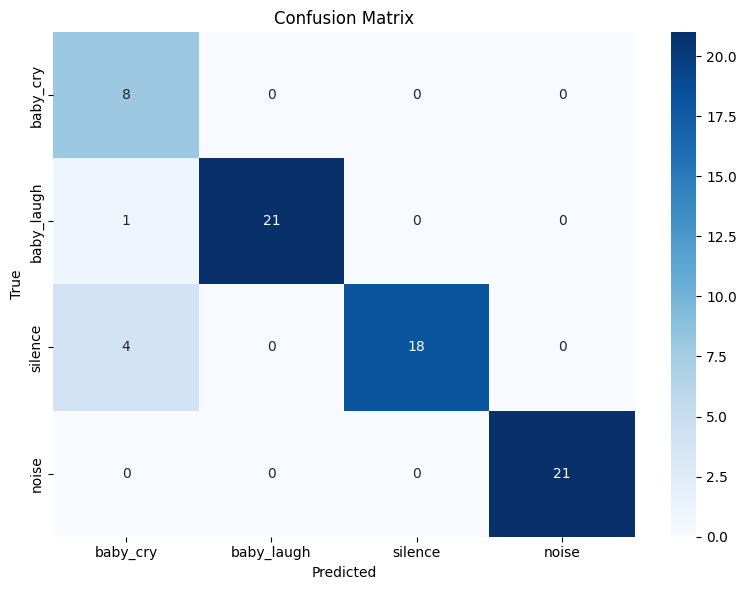

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Assuming you already have:
# - X_test: your test features
# - y_test: your one-hot encoded test labels
# - model: your trained model
# - categories: list of class names

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=categories))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [1]:
import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model("baby_sound_classifier.h5")

# Convert to TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the .tflite file
with open("baby_sound_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("Model converted and saved as baby_sound_classifier.tflite")


INFO:tensorflow:Assets written to: C:\Users\smsan\AppData\Local\Temp\tmpg9tj8zju\assets


INFO:tensorflow:Assets written to: C:\Users\smsan\AppData\Local\Temp\tmpg9tj8zju\assets


Saved artifact at 'C:\Users\smsan\AppData\Local\Temp\tmpg9tj8zju'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 216, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1790767559312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790767559504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790767560272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790767561232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790767559888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790767559696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790767561808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790769350224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790769348880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790769349456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1790769